# Synapsys — Notebook de Referência

## Objetivo

Este notebook demonstra as principais funcionalidades da biblioteca **synapsys** usando **um único sistema de referência** ao longo de todas as seções. O objetivo central é mostrar que:

> **Todas as formas de representar e simular o mesmo sistema linear são matematicamente equivalentes e produzem o mesmo resultado numérico.**

| Seção | Conteúdo | API principal |
|---|---|---|
| 1 | Função de Transferência e Espaço de Estados | `tf()`, `ss()` |
| 2 | **Comparativo de equivalência** (TF, SS, discreto, `evolve()`) | `step()`, `evolve()` |
| 3 | Métodos de discretização | `c2d()` |
| 4 | Álgebra de diagramas de blocos | `feedback()`, `series()` |
| 5 | Análise em frequência | `bode()` |
| 6 | Controlador PID em malha fechada | `PID` |
| 7 | Regulador LQR (realimentação de estados) | `lqr()` |
| 8 | Simulação em tempo real com agentes | `PlantAgent`, `ControllerAgent` |

---

## Sistema de Referência

Todas as seções utilizam **o mesmo sistema de segunda ordem subamortecido**:

$$G(s) = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n\,s + \omega_n^2} = \frac{25}{s^2 + 5s + 25}$$

com $\omega_n = 5\,\text{rad/s}$ e $\zeta = 0{,}5$. Este sistema é estável, tem ganho DC unitário e exibe uma resposta oscilatória amortecida característica de muitos sistemas físicos reais (suspensão de veículo, braço robótico, circuito RLC subamortecido etc.).

A forma em espaço de estados equivalente (forma canônica controlável) é:

$$\dot{x} = \underbrace{\begin{bmatrix}0 & 1\\-25 & -5\end{bmatrix}}_{A}x + \underbrace{\begin{bmatrix}0\\25\end{bmatrix}}_{B}u, \qquad y = \underbrace{\begin{bmatrix}1 & 0\end{bmatrix}}_{C}x$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.30,
    'lines.linewidth': 1.8,
    'font.size': 11,
})

# ── Parâmetros do sistema de referência ───────────────────────────────────────
WN   = 5.0    # frequência natural (rad/s)
ZETA = 0.5    # coeficiente de amortecimento

print(f"Sistema de referência: G(s) = {WN**2:.0f} / (s² + {2*ZETA*WN:.0f}s + {WN**2:.0f})")
print(f"  ωn = {WN} rad/s  |  ζ = {ZETA}  |  tipo: subamortecido (ζ < 1)")

Sistema de referência: G(s) = 25 / (s² + 5s + 25)
  ωn = 5.0 rad/s  |  ζ = 0.5  |  tipo: subamortecido (ζ < 1)


---
## 1. Função de Transferência e Espaço de Estados

A **função de transferência** $G(s)$ e o **espaço de estados** $(A, B, C, D)$ são duas representações diferentes do mesmo sistema dinâmico linear.

- `tf(num, den)` constrói o modelo a partir dos coeficientes polinomiais do numerador e denominador.
- `ss(A, B, C, D)` constrói o modelo a partir das matrizes do sistema.

Ambos expõem a mesma interface: `.poles()`, `.is_stable()`, `.evaluate(s)` e são intercambiáveis em `step()`, `bode()` e `c2d()`.

In [2]:
from synapsys.api import tf, ss, step, bode, feedback, c2d

# ── 1a. Função de Transferência ───────────────────────────────────────────────
G_tf = tf([WN**2], [1, 2*ZETA*WN, WN**2])

print("=== Função de Transferência ===")
print(G_tf)
print(f"  Polos : {G_tf.poles()}")
print(f"  Zeros : {G_tf.zeros()}")
print(f"  Ganho DC (s→0) : {G_tf.evaluate(0):.4f}")
print(f"  Estável : {G_tf.is_stable()}")

print()

# ── 1b. Espaço de Estados (forma canônica controlável) ────────────────────────
A = np.array([[0.0,        1.0    ],
              [-WN**2,  -2*ZETA*WN]])
B = np.array([[0.0  ],
              [WN**2]])
C = np.array([[1.0, 0.0]])
D = np.array([[0.0]])

G_ss = ss(A, B, C, D)

print("=== Espaço de Estados ===")
print(G_ss)
print(f"  Polos : {G_ss.poles()}")
print(f"  n_estados : {G_ss.n_states}")
print(f"  Estável : {G_ss.is_stable()}")

print()
print("Verificação: os polos são idênticos nas duas representações?")
poles_match = np.allclose(
    np.sort_complex(G_tf.poles()),
    np.sort_complex(G_ss.poles())
)
print(f"  Polos coincidem: {poles_match}  ✓" if poles_match else f"  DIVERGÊNCIA nos polos!")

=== Função de Transferência ===
TransferFunction(num=[25.0], den=[1.0, 5.0, 25.0], continuous)
  Polos : [-2.5+4.33012702j -2.5-4.33012702j]
  Zeros : []
  Ganho DC (s→0) : 1.0000+0.0000j
  Estável : True

=== Espaço de Estados ===
StateSpace(n_states=2, n_inputs=1, n_outputs=1, continuous)
  Polos : [-2.5+4.33012702j -2.5-4.33012702j]
  n_estados : 2
  Estável : True

Verificação: os polos são idênticos nas duas representações?
  Polos coincidem: True  ✓


---
## 2. Equivalência das Representações — todos os métodos produzem o mesmo resultado

Esta é a seção central do notebook. Calculamos a resposta ao degrau do **mesmo sistema** usando quatro abordagens distintas:

| Método | Como funciona |
|---|---|
| `step(G_tf)` | Integração da TF contínua via SciPy (`lsim` com degrau unitário) |
| `step(G_ss)` | Integração do SS contínuo via SciPy (`lsim` com degrau unitário) |
| `step(G_tf_d)` | Resposta ao degrau do modelo **TF discreto** (ZOH) |
| `evolve()` manual | Loop sample-a-sample no modelo **SS discreto** (ZOH) |

Os métodos contínuos devem coincidir até a precisão da máquina. Os métodos discretos introduzem um **erro de discretização** proporcional a $\Delta t$; quanto menor $\Delta t$, mais próximo do contínuo.

> **Por que isso importa?** Em engenharia de controle você pode mudar de representação a qualquer momento sem perder fidelidade. A escolha entre TF ou SS é de conveniência, não de precisão.

/home/osfarias/workspace/workspace_mestrado/pycontrol/.venv/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


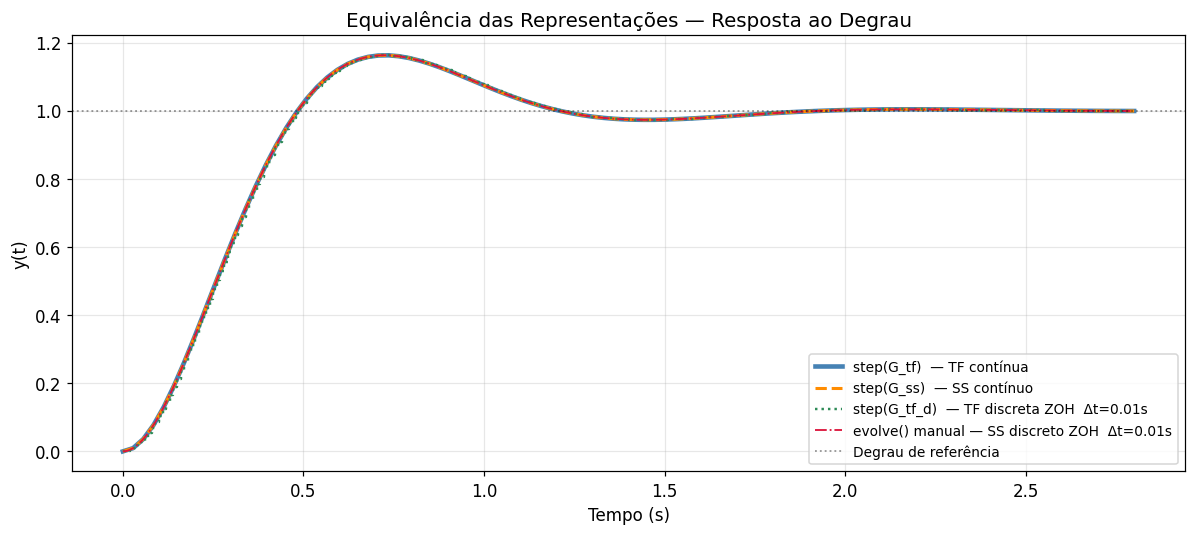

Erro máximo em relação à TF contínua:
  TF contínua  vs  SS contínuo     : 1.55e-15  ← erro numérico de máquina
  TF contínua  vs  TF discreta ZOH : 0.00020   ← erro de discretização (Δt=0.01s)
  TF contínua  vs  evolve() manual  : 0.00020   ← idêntico ao passo anterior

Conclusão: TF e SS contínuos são numericamente idênticos.
           evolve() manual e step() discreto são equivalentes (mesma estrutura interna).


In [3]:
DT_CMP = 0.01   # 100 Hz — resolução da simulação discreta

# ── Método 1: step() na TF contínua ──────────────────────────────────────────
t_tf, y_tf = step(G_tf)

# ── Método 2: step() no SS contínuo ──────────────────────────────────────────
t_ss, y_ss = step(G_ss)

# ── Método 3: step() na TF discretizada (ZOH) ────────────────────────────────
G_tf_d = c2d(G_tf, dt=DT_CMP, method='zoh')
N_cmp  = int(t_tf[-1] / DT_CMP) + 1
t_tfd, y_tfd = step(G_tf_d, n=N_cmp)

# ── Método 4: loop manual com evolve() no SS discreto (ZOH) ──────────────────
G_ss_d = c2d(G_ss, dt=DT_CMP, method='zoh')
x_man  = np.zeros(G_ss_d.n_states)   # estado inicial zero
y_man  = np.zeros(N_cmp)

for k in range(N_cmp):
    x_man, y_k = G_ss_d.evolve(x_man, np.array([1.0]))   # degrau unitário u=1
    y_man[k]   = float(y_k[0])

t_man = np.arange(N_cmp) * DT_CMP

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot (t_tf,  y_tf,  lw=3.0, color='steelblue',  label='step(G_tf)  — TF contínua')
ax.plot (t_ss,  y_ss,  lw=2.0, color='darkorange', linestyle='--',
         label='step(G_ss)  — SS contínuo')
ax.step (t_tfd, y_tfd, lw=1.6, color='seagreen',   where='post', linestyle=':',
         label=f'step(G_tf_d)  — TF discreta ZOH  Δt={DT_CMP}s')
ax.plot (t_man, y_man, lw=1.2, color='crimson',    linestyle='-.',
         label=f'evolve() manual — SS discreto ZOH  Δt={DT_CMP}s')
ax.axhline(1.0, color='k', linestyle=':', lw=1.2, alpha=0.4, label='Degrau de referência')

ax.set_title('Equivalência das Representações — Resposta ao Degrau', fontsize=13)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('y(t)')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
plt.show()

# ── Verificação numérica dos erros ────────────────────────────────────────────
y_ss_i  = np.interp(t_tf, t_ss,  y_ss)
y_tfd_i = np.interp(t_tf, t_tfd, y_tfd)
y_man_i = np.interp(t_tf, t_man, y_man)

print("Erro máximo em relação à TF contínua:")
print(f"  TF contínua  vs  SS contínuo     : {np.max(np.abs(y_tf - y_ss_i)):.2e}  ← erro numérico de máquina")
print(f"  TF contínua  vs  TF discreta ZOH : {np.max(np.abs(y_tf - y_tfd_i)):.5f}   ← erro de discretização (Δt={DT_CMP}s)")
print(f"  TF contínua  vs  evolve() manual  : {np.max(np.abs(y_tf - y_man_i)):.5f}   ← idêntico ao passo anterior")
print()
print("Conclusão: TF e SS contínuos são numericamente idênticos.")
print("           evolve() manual e step() discreto são equivalentes (mesma estrutura interna).")

---
## 3. Métodos de Discretização

`c2d(sys, dt, method)` converte um modelo contínuo para discreto. A synapsys suporta quatro métodos:

| Método | Descrição | Quando usar |
|---|---|---|
| `'zoh'` | Zero-Order Hold — exato para entradas constantes por período | Padrão; melhor fidelidade |
| `'bilinear'` | Transformação de Tustin $s = \frac{2}{\Delta t}\frac{z-1}{z+1}$ | Preserva a forma do Bode |
| `'euler'` | Diferenças finitas para frente $s = \frac{z-1}{\Delta t}$ | Simples, menos preciso |
| `'backward_diff'` | Diferenças finitas para trás $s = \frac{z-1}{z\,\Delta t}$ | Sempre estável se contínuo é estável |

A escolha do método e do passo $\Delta t$ afeta a precisão. Aqui comparamos todos contra a resposta contínua de referência.

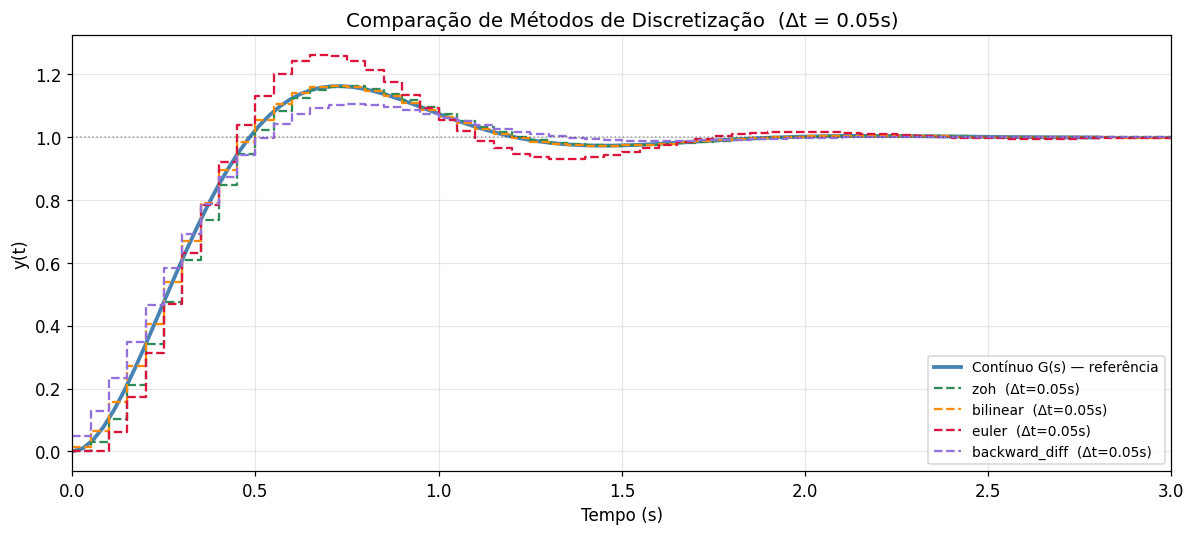

Erro máximo de cada método em relação ao contínuo  (Δt = 0.05s):
  zoh            : 0.00668
  bilinear       : 0.06457
  euler          : 0.11678
  backward_diff  : 0.13623

Observação: ZOH e bilinear são mais precisos que os métodos de Euler para o mesmo Δt.


In [4]:
DT_C2D = 0.05   # 20 Hz — passo maior para evidenciar diferenças entre métodos
N_c2d  = int(3.0 / DT_C2D) + 1

methods = ['zoh', 'bilinear', 'euler', 'backward_diff']
colors  = ['seagreen', 'darkorange', 'crimson', 'mediumpurple']

fig, ax = plt.subplots(figsize=(11, 5))

# Referência contínua
t_ref, y_ref = step(G_tf)
ax.plot(t_ref, y_ref, lw=2.5, color='steelblue', label='Contínuo G(s) — referência')

# Modelos discretos
for method, color in zip(methods, colors):
    G_d   = c2d(G_tf, dt=DT_C2D, method=method)
    t_d, y_d = step(G_d, n=N_c2d)
    ax.step(t_d, y_d, where='post', lw=1.5, color=color, linestyle='--',
            label=f'{method}  (Δt={DT_C2D}s)')

ax.axhline(1.0, color='k', linestyle=':', lw=1.0, alpha=0.35)
ax.set_title(f'Comparação de Métodos de Discretização  (Δt = {DT_C2D}s)', fontsize=13)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('y(t)')
ax.set_xlim(0, 3.0)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── Tabela de erro de discretização ──────────────────────────────────────────
print(f"Erro máximo de cada método em relação ao contínuo  (Δt = {DT_C2D}s):")
for method in methods:
    G_d = c2d(G_tf, dt=DT_C2D, method=method)
    t_d, y_d = step(G_d, n=N_c2d)
    y_d_i = np.interp(t_ref, t_d, y_d)
    err   = np.max(np.abs(y_ref - y_d_i))
    print(f"  {method:<15}: {err:.5f}")

print()
print("Observação: ZOH e bilinear são mais precisos que os métodos de Euler para o mesmo Δt.")

---
## 4. Álgebra de Diagramas de Blocos

A synapsys suporta operações algébricas diretas sobre modelos LTI:

- **Série:** `G1 * G2`  ou  `series(G1, G2)` → $G_1(s)\cdot G_2(s)$
- **Paralelo:** `G1 + G2`  ou  `parallel(G1, G2)` → $G_1(s) + G_2(s)$
- **Malha fechada:** `feedback(L)` → $T(s) = \dfrac{L(s)}{1 + L(s)}$ (realimentação unitária negativa)

### Topologia padrão (controlador na via direta)

```
r ──▶[+]──▶[ Ctrl ]──▶[ G ]──▶ y
      ▲─────────────────────────┘
               (−)
```

A função de transferência de malha fechada é:

$$T(s) = \frac{C(s)\,G(s)}{1 + C(s)\,G(s)}$$

### Erro estacionário com controlador proporcional

Com $C(s) = K_p$ (sem integrador), o **erro estacionário para entrada degrau** é:

$$e_{ss} = \frac{1}{1 + K_p\,G(0)} \neq 0$$

Para erro zero, é necessário ao menos um integrador na malha aberta (controlador PI ou planta tipo 1). Isso é uma consequência direta do **Teorema do Valor Final**.

=== Malha Aberta  L(s) = Ctrl(s)·G(s) ===
TransferFunction(num=[50.0], den=[1.0, 5.0, 25.0], continuous)
  Polos: [-2.5+4.33012702j -2.5-4.33012702j]
  Ganho DC: 2.0000+0.0000j

=== Malha Fechada  T(s) = L(s)/(1+L(s)) ===
TransferFunction(num=[50.0], den=[1.0, 5.0, 75.0], continuous)
  Polos: [-2.5+8.29156198j -2.5-8.29156198j]
  Ganho DC: 0.6667
  Erro estacionário (degrau unitário): e_ss = 1/(1+Kp·G(0)) = 0.3333

  Verificação analítica: 1/(1 + 2.0×1.0) = 0.3333

  ─── Por que há erro estacionário? ───────────────────────────────────
  Com C(s)=Kp puro (sem integrador), a malha aberta L(s) é de tipo 0.
  Pelo Teorema do Valor Final: e_ss = lim s→0 de s·E(s)/s = 1/(1+L(0))
  Para erro zero: adicione um integrador (controlador PI) ou use PID/LQR.


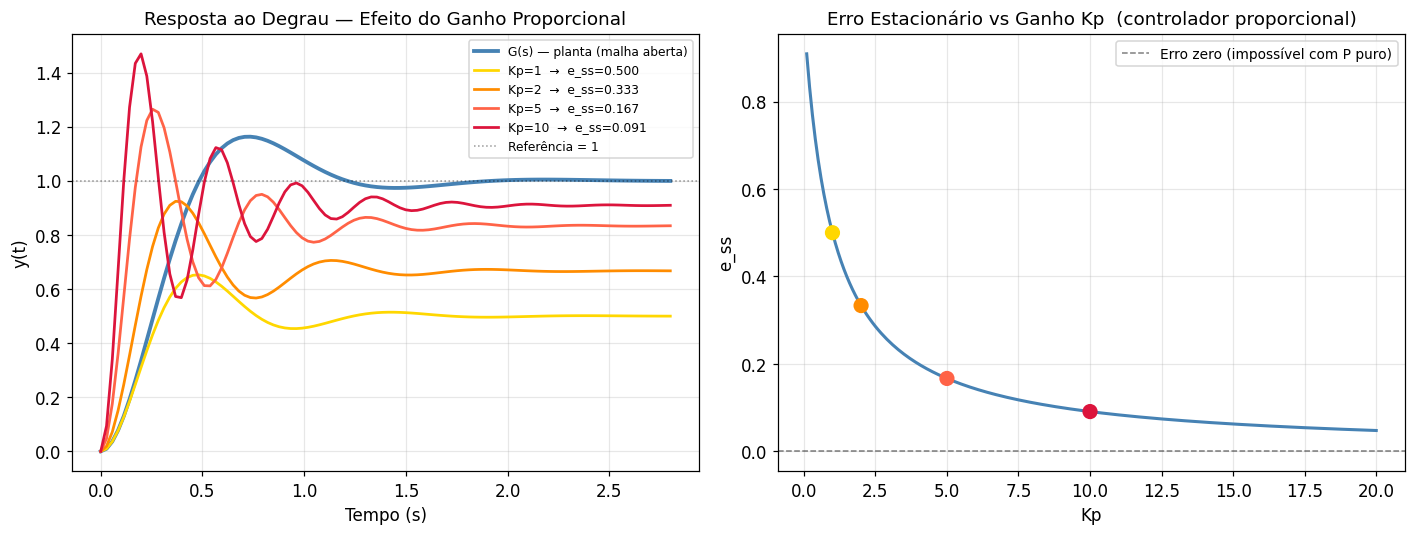

In [5]:
from synapsys.api import series, parallel

# ── Controlador proporcional Ctrl(s) = Kp ────────────────────────────────────
Kp   = 2.0
Ctrl = tf([Kp], [1])   # ganho puro

# ── Malha aberta: L(s) = Ctrl(s)·G(s)  (controlador na via direta) ───────────
L = series(Ctrl, G_tf)

# ── Malha fechada: T(s) = L(s)/(1+L(s))  (realimentação unitária negativa) ───
T = feedback(L)

print("=== Malha Aberta  L(s) = Ctrl(s)·G(s) ===")
print(L)
print(f"  Polos: {L.poles()}")
print(f"  Ganho DC: {L.evaluate(0):.4f}")

print()
print("=== Malha Fechada  T(s) = L(s)/(1+L(s)) ===")
print(T)
dc_T = T.evaluate(0).real
e_ss = 1 - dc_T
print(f"  Polos: {T.poles()}")
print(f"  Ganho DC: {dc_T:.4f}")
print(f"  Erro estacionário (degrau unitário): e_ss = 1/(1+Kp·G(0)) = {e_ss:.4f}")
print()
print(f"  Verificação analítica: 1/(1 + {Kp}×{G_tf.evaluate(0).real:.1f}) = {1/(1+Kp*G_tf.evaluate(0).real):.4f}")
print()
print("  ─── Por que há erro estacionário? ───────────────────────────────────")
print("  Com C(s)=Kp puro (sem integrador), a malha aberta L(s) é de tipo 0.")
print("  Pelo Teorema do Valor Final: e_ss = lim s→0 de s·E(s)/s = 1/(1+L(0))")
print("  Para erro zero: adicione um integrador (controlador PI) ou use PID/LQR.")

# ── Gráficos: comparativo de diferentes ganhos Kp ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Resposta ao degrau — planta vs malha fechada para diferentes Kp
t_plant, y_plant = step(G_tf)
ax1.plot(t_plant, y_plant, lw=2.5, color='steelblue',
         label='G(s) — planta (malha aberta)')

kp_vals   = [1.0, 2.0, 5.0, 10.0]
kp_colors = ['gold', 'darkorange', 'tomato', 'crimson']

for kp_i, col in zip(kp_vals, kp_colors):
    T_i    = feedback(series(tf([kp_i], [1]), G_tf))
    t_i, y_i = step(T_i)
    dc_i   = T_i.evaluate(0).real
    e_i    = 1 - dc_i
    ax1.plot(t_i, y_i, lw=1.8, color=col,
             label=f'Kp={kp_i:.0f}  →  e_ss={e_i:.3f}')

ax1.axhline(1.0, color='k', linestyle=':', lw=1.0, alpha=0.4, label='Referência = 1')
ax1.set_title('Resposta ao Degrau — Efeito do Ganho Proporcional', fontsize=12)
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('y(t)')
ax1.legend(fontsize=8)

# Erro estacionário vs Kp (curva analítica)
kp_range = np.linspace(0.1, 20, 200)
ess_range = 1.0 / (1.0 + kp_range * G_tf.evaluate(0).real)
ax2.plot(kp_range, ess_range, lw=2.0, color='steelblue')
ax2.axhline(0, color='k', linestyle='--', lw=1.0, alpha=0.5, label='Erro zero (impossível com P puro)')
ax2.scatter(kp_vals, [1/(1+k*G_tf.evaluate(0).real) for k in kp_vals],
            color=kp_colors, s=80, zorder=5)
ax2.set_title('Erro Estacionário vs Ganho Kp  (controlador proporcional)', fontsize=12)
ax2.set_xlabel('Kp')
ax2.set_ylabel('e_ss')
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

---
## 5. Análise em Frequência — Diagrama de Bode

O diagrama de Bode mostra como o sistema responde a entradas senoidais em diferentes frequências:

- **Magnitude:** ganho $|G(j\omega)|$ em dB — quanto a amplitude de saída é ampliada ou atenuada.
- **Fase:** defasagem $\angle G(j\omega)$ em graus — o atraso ou avanço da saída em relação à entrada.

`bode(sys)` retorna `(ω, magnitude_dB, phase_deg)` — mesma convenção do MATLAB.

Para o sistema de referência esperamos:
- Ressonância em $\omega \approx \omega_n\sqrt{1-2\zeta^2}$ (pico de magnitude).
- Fase de $-90°$ em $\omega = \omega_n$.
- Queda de $-40\,\text{dB/dec}$ para $\omega \gg \omega_n$ (sistema de 2ª ordem).

Sobrepomos TF e SS para confirmar que os diagramas são idênticos.

/home/osfarias/workspace/workspace_mestrado/pycontrol/.venv/lib/python3.12/site-packages/scipy/signal/_filter_design.py:1233: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


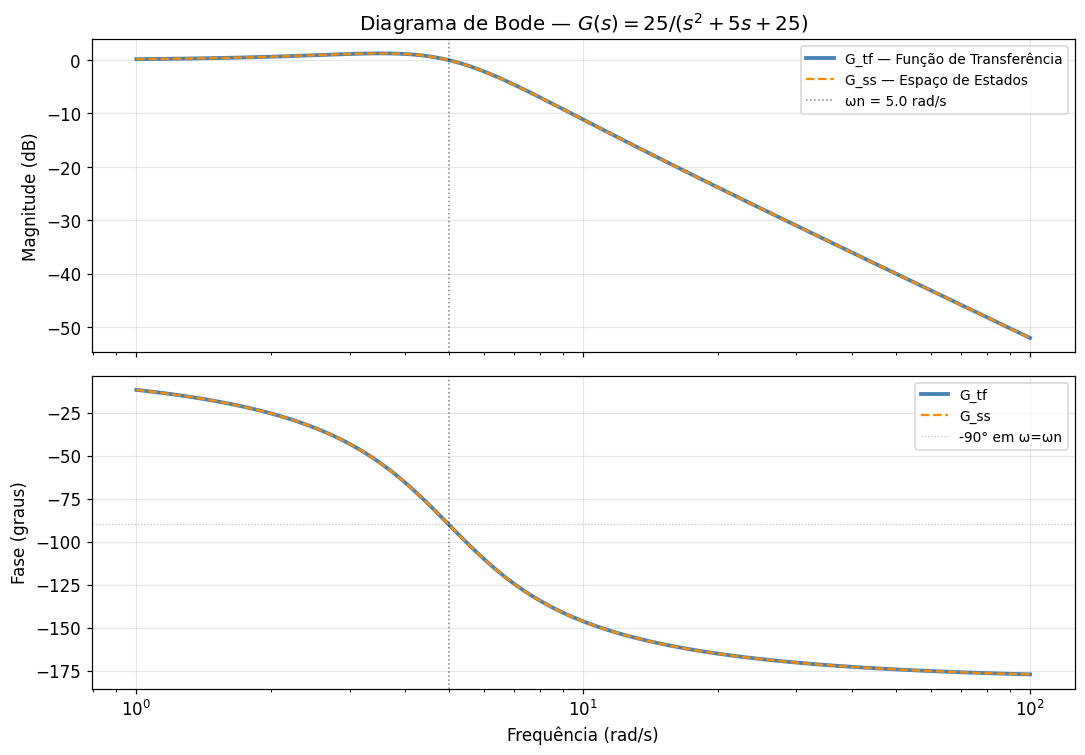

Erro máximo de magnitude entre TF e SS: 1.42e-14  ← erro numérico de máquina


In [6]:
w_tf,  mag_tf,  phase_tf  = bode(G_tf)
w_ss,  mag_ss,  phase_ss  = bode(G_ss)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Magnitude
ax1.semilogx(w_tf, mag_tf,   lw=2.5, color='steelblue',  label='G_tf — Função de Transferência')
ax1.semilogx(w_ss, mag_ss,   lw=1.5, color='darkorange', linestyle='--', label='G_ss — Espaço de Estados')
ax1.axvline(WN, color='k',   linestyle=':', lw=1.0, alpha=0.5, label=f'ωn = {WN} rad/s')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title(r'Diagrama de Bode — $G(s) = 25/(s^2+5s+25)$', fontsize=13)
ax1.legend(fontsize=9)

# Fase
ax2.semilogx(w_tf, phase_tf, lw=2.5, color='steelblue',  label='G_tf')
ax2.semilogx(w_ss, phase_ss, lw=1.5, color='darkorange', linestyle='--', label='G_ss')
ax2.axvline(WN, color='k',   linestyle=':', lw=1.0, alpha=0.5)
ax2.axhline(-90, color='gray', linestyle=':', lw=0.8, alpha=0.5, label='-90° em ω=ωn')
ax2.set_ylabel('Fase (graus)')
ax2.set_xlabel('Frequência (rad/s)')
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

# ── Verificação numérica ──────────────────────────────────────────────────────
err_bode = np.max(np.abs(mag_tf - np.interp(w_tf, w_ss, mag_ss)))
print(f"Erro máximo de magnitude entre TF e SS: {err_bode:.2e}  ← erro numérico de máquina")

---
## 6. Controlador PID em Malha Fechada

O `PID` discreto da synapsys implementa o algoritmo de velocidade com:
- **Anti-windup** por back-calculation (evita saturação do integrador).
- **Saturação da saída** configurável (`u_min`, `u_max`).

Simulamos manualmente o loop de controle a cada passo de tempo usando a **mesma planta de referência** discretizada a 100 Hz:

```
┌──────────┐    u(k)    ┌──────────┐    y(k)
│   PID    │──────────▶ │  Planta  │──────────▶
└──────────┘            └──────────┘
      ▲                                  │
      │         e(k) = r(k) − y(k)       │
      └─────────────────────────────────-┘
```

O referencial (setpoint) é uma **senoide** $r(t) = 3 + 1.5\sin(2\pi \cdot 0.3\, t)$ para tornar a resposta dinâmica mais informativa.

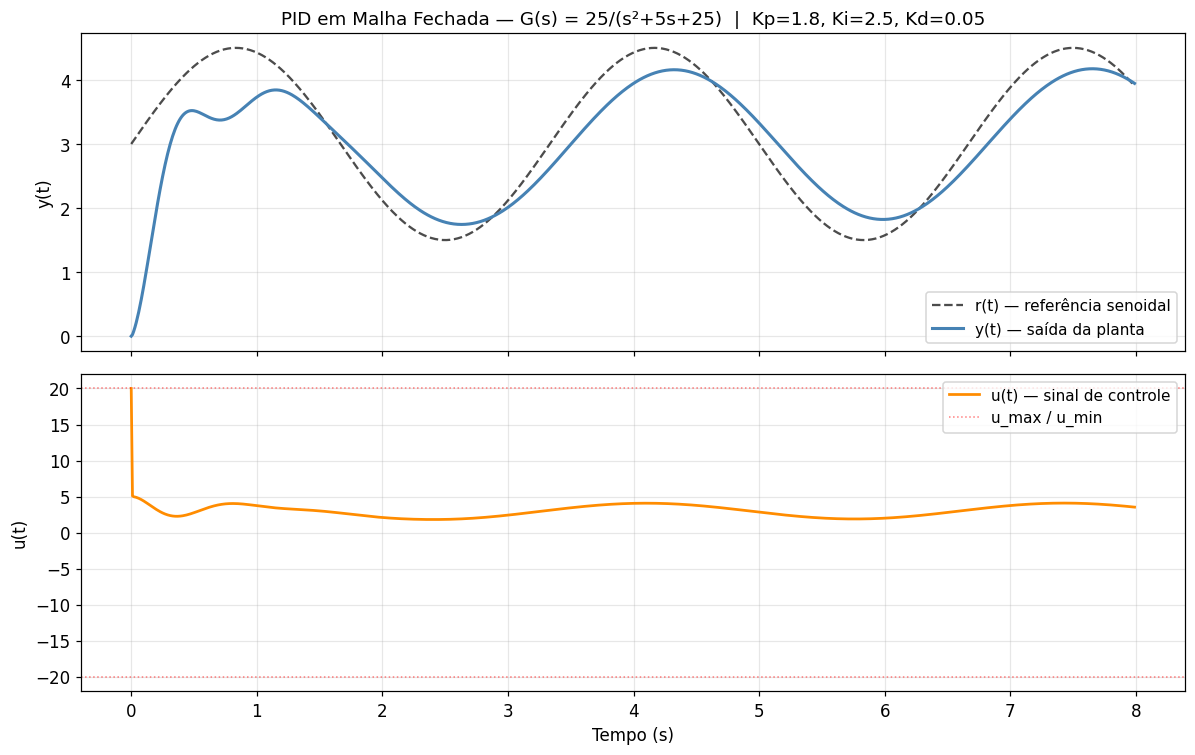

Erro RMS (regime permanente, t > 2s): 0.3493
Erro máximo absoluto              : 3.0037


In [7]:
from synapsys.algorithms import PID

DT_PID = 0.01    # 100 Hz
T_PID  = 8.0     # segundos de simulação
N_PID  = int(T_PID / DT_PID)

# ── Planta: G(s) discretizada com ZOH ────────────────────────────────────────
plant_d = c2d(G_ss, dt=DT_PID, method='zoh')

# ── PID sintonizado para o sistema de referência ──────────────────────────────
# Parâmetros escolhidos empiricamente para boa resposta transitória
pid = PID(Kp=1.8, Ki=2.5, Kd=0.05, dt=DT_PID, u_min=-20.0, u_max=20.0)

# ── Referência senoidal: r(t) = 3 + 1.5·sin(2π·0.3·t) ───────────────────────
def setpoint(t):
    return 3.0 + 1.5 * np.sin(2 * np.pi * 0.3 * t)

# ── Loop de simulação ─────────────────────────────────────────────────────────
x = np.zeros(plant_d.n_states)   # estado inicial zero
ts, ys, us, rs = [], [], [], []

for k in range(N_PID):
    t_k = k * DT_PID
    r_k = setpoint(t_k)

    # Saída atual da planta  (C·x, C shape (1,n), x shape (n,) → escalar)
    y_k = float(np.dot(plant_d.C[0], x))

    # Ação de controle
    u_k = pid.compute(setpoint=r_k, measurement=y_k)

    # Evolução do estado
    x, _ = plant_d.evolve(x, np.array([u_k]))

    ts.append(t_k)
    ys.append(y_k)
    us.append(u_k)
    rs.append(r_k)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(ts, rs, lw=1.5, color='k',          linestyle='--', alpha=0.7,
         label='r(t) — referência senoidal')
ax1.plot(ts, ys, lw=2.0, color='steelblue',
         label='y(t) — saída da planta')
ax1.set_ylabel('y(t)')
ax1.set_title(f'PID em Malha Fechada — G(s) = 25/(s²+5s+25)  |  Kp={pid.Kp}, Ki={pid.Ki}, Kd={pid.Kd}',
              fontsize=12)
ax1.legend(fontsize=10)

ax2.plot(ts, us, lw=1.8, color='darkorange', label='u(t) — sinal de controle')
ax2.axhline( 20.0, color='r', linestyle=':', lw=1.0, alpha=0.5, label='u_max / u_min')
ax2.axhline(-20.0, color='r', linestyle=':', lw=1.0, alpha=0.5)
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('u(t)')
ax2.legend(fontsize=10)

fig.tight_layout()
plt.show()

# ── Métricas de desempenho ────────────────────────────────────────────────────
erro = np.array(rs) - np.array(ys)
print(f"Erro RMS (regime permanente, t > 2s): {np.sqrt(np.mean(erro[200:]**2)):.4f}")
print(f"Erro máximo absoluto              : {np.max(np.abs(erro)):.4f}")

---
## 7. Regulador LQR — Rastreamento de Referência

O LQR por design **regula para zero**: minimiza o desvio do estado em relação à origem. Para rastrear uma **referência não-nula** $r \neq 0$, usamos uma pré-compensação feedforward $\bar{N}$ (método "Nbar"):

$$u(t) = -K x(t) + \bar{N}\, r$$

O ganho $\bar{N}$ é calculado de forma que $y_{ss} = r$ em regime permanente. Derivação:

$$\text{Em regime: } 0 = (A - BK)\,x_{ss} + B\bar{N}r \implies x_{ss} = -(A-BK)^{-1}B\bar{N}r$$

$$y_{ss} = C_{\text{obs}}\,x_{ss} = r \implies \bar{N} = \frac{-1}{C_{\text{obs}}\,(A-BK)^{-1}B}$$

O diagrama de controle com $\bar{N}$ é:

```
         ┌────────────────────────────────────────┐
r ──Nbar─┤+─▶[ u = -Kx + Nbar·r ]──▶[ Planta ]──▶ y
         │         ▲                        │
         │         │     x (estados)        │
         └─────────┴────────────────────────┘
```

**Importante:** $\bar{N}$ garante erro zero apenas para referências **constantes** (degrau). Para referências variáveis no tempo (rampa, senoide) é necessário ação integral nos estados.

In [8]:
from synapsys.algorithms import lqr

# Linha de observação do SS: y = x₁  (primeira linha de C = [[1, 0]])
C_obs = np.array([1.0, 0.0])

print("Matrizes do sistema de referência:")
print(f"  A =\n{A}")
print(f"  B = {B.flatten()}")
print(f"  C_obs = {C_obs}  (y = x₁)")

# ── Pesos LQR ────────────────────────────────────────────────────────────────
Q = np.diag([20.0, 1.0])   # penaliza mais x1 (saída) do que x2 (derivada)
R = np.array([[1.0]])

K, P = lqr(A, B, Q, R)

print(f"\nGanho ótimo K = {K}")
print(f"Matriz de custo P =\n{P}")

# ── Polos da malha fechada ────────────────────────────────────────────────────
A_cl     = A - B @ K
cl_poles = np.linalg.eigvals(A_cl)
print(f"\nPolos em malha aberta  : {np.linalg.eigvals(A)}")
print(f"Polos em malha fechada : {cl_poles}  (LQR deslocou para esquerda)")
print(f"Todos Re(p) < 0 (estável): {np.all(np.real(cl_poles) < 0)}")

# ── Ganho de pré-compensação Nbar ─────────────────────────────────────────────
# Garante y_ss = r para referência constante
# Nbar = -1 / (C_obs · inv(A_cl) · B)
Nbar = float(-1.0 / (C_obs @ np.linalg.solve(A_cl, B.flatten())))
print(f"\nGanho de pré-compensação  Nbar = {Nbar:.4f}")
print(f"  Lei de controle: u(t) = -K·x(t) + Nbar·r")
print(f"  Verificação: y_ss = C·inv(A-BK)·(-B·Nbar·r) → deve → r  ✓")

Matrizes do sistema de referência:
  A =
[[  0.   1.]
 [-25.  -5.]]
  B = [ 0. 25.]
  C_obs = [1. 0.]  (y = x₁)

Ganho ótimo K = [[3.58257569 0.95178386]]
Matriz de custo P =
[[5.07813671 0.14330303]
 [0.14330303 0.03807135]]

Polos em malha aberta  : [-2.5+4.33012702j -2.5-4.33012702j]
Polos em malha fechada : [ -4.76828977 -24.02630668]  (LQR deslocou para esquerda)
Todos Re(p) < 0 (estável): True

Ganho de pré-compensação  Nbar = 4.5826
  Lei de controle: u(t) = -K·x(t) + Nbar·r
  Verificação: y_ss = C·inv(A-BK)·(-B·Nbar·r) → deve → r  ✓


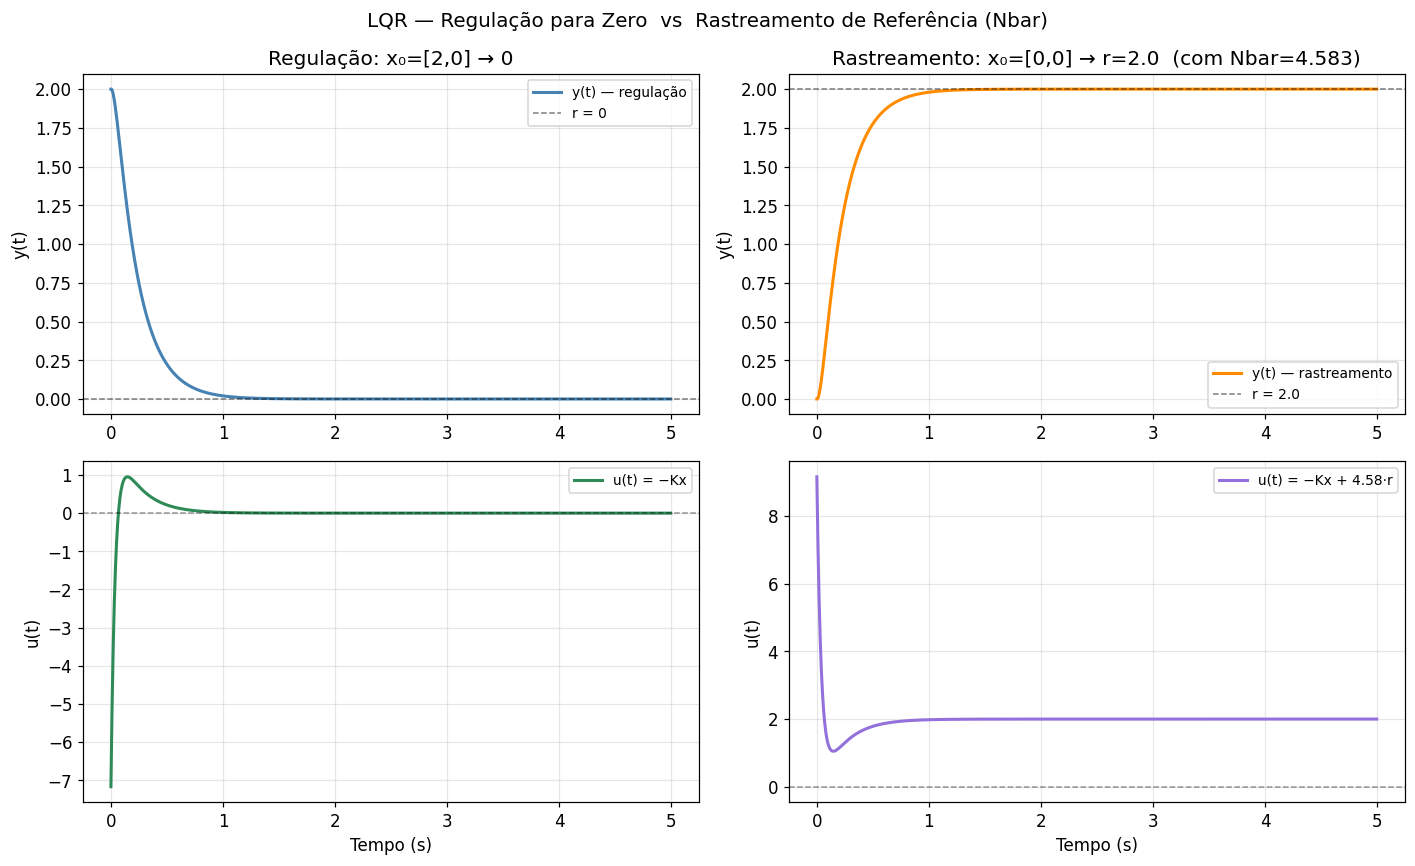

Regulação  — y_ss = 0.000000  (esperado: 0.0)
Rastreamento — y_ss = 2.000000  (esperado: 2.0)
  Erro em regime: 8.47e-11  ← praticamente zero ✓

Custo J (regulação)    ≈ 12.5808
Custo J (rastreamento) ≈ 32.1701


In [9]:
# ── Simulação: regulação pura (r=0) vs rastreamento com Nbar ─────────────────
DT_LQR = 0.005   # 200 Hz
T_LQR  = 5.0
steps  = int(T_LQR / DT_LQR)

SETPOINT_LQR = 2.0   # referência não-nula

# Caso 1: regulação pura (sem Nbar) — x0 = [2, 0], referência = 0
x_reg  = np.array([2.0, 0.0])
# Caso 2: rastreamento com Nbar — x0 = [0, 0], referência = 2.0
x_trk  = np.zeros(2)

t_hist  = []
y_reg_hist, u_reg_hist = [], []
y_trk_hist, u_trk_hist = [], []

for k in range(steps):
    t_k = k * DT_LQR

    # ── Caso 1: regulação (u = -Kx) ───────────────────────────────────────
    u_reg = float(-(K @ x_reg).flat[0])
    y_reg = float(np.dot(C_obs, x_reg))
    x_reg = x_reg + DT_LQR * (A @ x_reg + B.flatten() * u_reg)

    # ── Caso 2: rastreamento (u = -Kx + Nbar·r) ───────────────────────────
    u_trk = float(-(K @ x_trk).flat[0]) + Nbar * SETPOINT_LQR
    y_trk = float(np.dot(C_obs, x_trk))
    x_trk = x_trk + DT_LQR * (A @ x_trk + B.flatten() * u_trk)

    t_hist.append(t_k)
    y_reg_hist.append(y_reg)
    u_reg_hist.append(u_reg)
    y_trk_hist.append(y_trk)
    u_trk_hist.append(u_trk)

t_arr = np.array(t_hist)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('LQR — Regulação para Zero  vs  Rastreamento de Referência (Nbar)', fontsize=13)

# ── Saídas ────────────────────────────────────────────────────────────────────
axes[0, 0].plot(t_arr, y_reg_hist, lw=2.0, color='steelblue',  label='y(t) — regulação')
axes[0, 0].axhline(0, color='k', linestyle='--', lw=1.0, alpha=0.5, label='r = 0')
axes[0, 0].set_title('Regulação: x₀=[2,0] → 0')
axes[0, 0].set_ylabel('y(t)')
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(t_arr, y_trk_hist, lw=2.0, color='darkorange', label='y(t) — rastreamento')
axes[0, 1].axhline(SETPOINT_LQR, color='k', linestyle='--', lw=1.0, alpha=0.5,
                   label=f'r = {SETPOINT_LQR}')
axes[0, 1].set_title(f'Rastreamento: x₀=[0,0] → r={SETPOINT_LQR}  (com Nbar={Nbar:.3f})')
axes[0, 1].set_ylabel('y(t)')
axes[0, 1].legend(fontsize=9)

# ── Controles ─────────────────────────────────────────────────────────────────
axes[1, 0].plot(t_arr, u_reg_hist, lw=2.0, color='seagreen',  label='u(t) = −Kx')
axes[1, 0].axhline(0, color='k', linestyle='--', lw=1.0, alpha=0.4)
axes[1, 0].set_ylabel('u(t)')
axes[1, 0].set_xlabel('Tempo (s)')
axes[1, 0].legend(fontsize=9)

axes[1, 1].plot(t_arr, u_trk_hist, lw=2.0, color='mediumpurple',
                label=f'u(t) = −Kx + {Nbar:.2f}·r')
axes[1, 1].axhline(0, color='k', linestyle='--', lw=1.0, alpha=0.4)
axes[1, 1].set_ylabel('u(t)')
axes[1, 1].set_xlabel('Tempo (s)')
axes[1, 1].legend(fontsize=9)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ── Verificação do erro estacionário ─────────────────────────────────────────
y_ss_reg = y_reg_hist[-1]
y_ss_trk = y_trk_hist[-1]
print(f"Regulação  — y_ss = {y_ss_reg:.6f}  (esperado: 0.0)")
print(f"Rastreamento — y_ss = {y_ss_trk:.6f}  (esperado: {SETPOINT_LQR})")
print(f"  Erro em regime: {abs(SETPOINT_LQR - y_ss_trk):.2e}  ← praticamente zero ✓")
print(f"\nCusto J (regulação)    ≈ {np.sum(np.array(y_reg_hist)**2 * 20 + np.array(u_reg_hist)**2) * DT_LQR:.4f}")
print(f"Custo J (rastreamento) ≈ {np.sum((np.array(y_trk_hist)-SETPOINT_LQR)**2 * 20 + np.array(u_trk_hist)**2) * DT_LQR:.4f}")

---
## 8. Simulação em Tempo Real com Agentes

A synapsys inclui um framework de simulação **multi-agente** onde planta e controlador rodam em **threads independentes** sincronizadas, comunicando-se por um barramento de memória compartilhada de latência < 1 µs.

```
PlantAgent  ──────── y ──────────▶  ControllerAgent
              ◀──── u ────────────
               SharedMemoryTransport
```

Componentes:
- **`PlantAgent`** — evolve a planta discreta a cada tick, publica `y`, consome `u`.
- **`ControllerAgent`** — lê `y`, calcula `u = law(y)`, escreve `u`.
- **`SyncEngine`** — gerencia a sincronização: `WALL_CLOCK` (tempo real) ou `LOCK_STEP` (barreira).
- **`SharedMemoryTransport`** — barramento zero-copy (sem serialização, sem rede).

Usamos **a mesma planta de referência** e o **mesmo controlador PID** da seção anterior, agora em threads separadas.

In [10]:
import time
from synapsys.agents import PlantAgent, ControllerAgent, SyncEngine, SyncMode
from synapsys.transport import SharedMemoryTransport

DT_AGT   = 0.01    # 100 Hz — mesmo DT da seção PID
SIM_TIME = 6.0     # segundos
BUS      = "nb_demo"
CHANNELS = {"y": 1, "u": 1}

# ── Planta: mesmo G(s) discretizado ──────────────────────────────────────────
plant_agt = c2d(G_ss, dt=DT_AGT, method='zoh')

# ── Barramento de memória compartilhada ──────────────────────────────────────
owner = SharedMemoryTransport(BUS, CHANNELS, create=True)
owner.write("y", np.array([0.0]))
owner.write("u", np.array([0.0]))

t_plant_h = SharedMemoryTransport(BUS, CHANNELS)
t_ctrl_h  = SharedMemoryTransport(BUS, CHANNELS)

# ── Lei de controle PID (mesmos ganhos da seção anterior) ─────────────────────
pid_agt  = PID(Kp=1.8, Ki=2.5, Kd=0.05, dt=DT_AGT, u_min=-20.0, u_max=20.0)

def law_agt(y: np.ndarray) -> np.ndarray:
    r = 3.0 + 1.5 * np.sin(2 * np.pi * 0.3 * (time.monotonic() - t0_agt))
    return np.array([pid_agt.compute(setpoint=r, measurement=y[0])])

# ── Criação dos agentes ───────────────────────────────────────────────────────
plant_agent = PlantAgent("plant", plant_agt, t_plant_h,
                         SyncEngine(SyncMode.WALL_CLOCK, dt=DT_AGT))
ctrl_agent  = ControllerAgent("ctrl", law_agt, t_ctrl_h,
                              SyncEngine(SyncMode.WALL_CLOCK, dt=DT_AGT))

# ── Coleta de dados do barramento (thread principal como monitor) ─────────────
log_t, log_y, log_u, log_r = [], [], [], []

t0_agt = time.monotonic()
plant_agent.start(blocking=False)
ctrl_agent.start(blocking=False)

while time.monotonic() - t0_agt < SIM_TIME:
    elapsed = time.monotonic() - t0_agt
    log_t.append(elapsed)
    log_y.append(owner.read("y")[0])
    log_u.append(owner.read("u")[0])
    log_r.append(3.0 + 1.5 * np.sin(2 * np.pi * 0.3 * elapsed))
    time.sleep(DT_AGT)

plant_agent.stop()
ctrl_agent.stop()
t_plant_h.close()
t_ctrl_h.close()
owner.close()

print(f"Coletadas {len(log_t)} amostras em {SIM_TIME}s")
print(f"Saída final y = {log_y[-1]:.4f}")

Coletadas 589 amostras em 6.0s
Saída final y = 1.8206


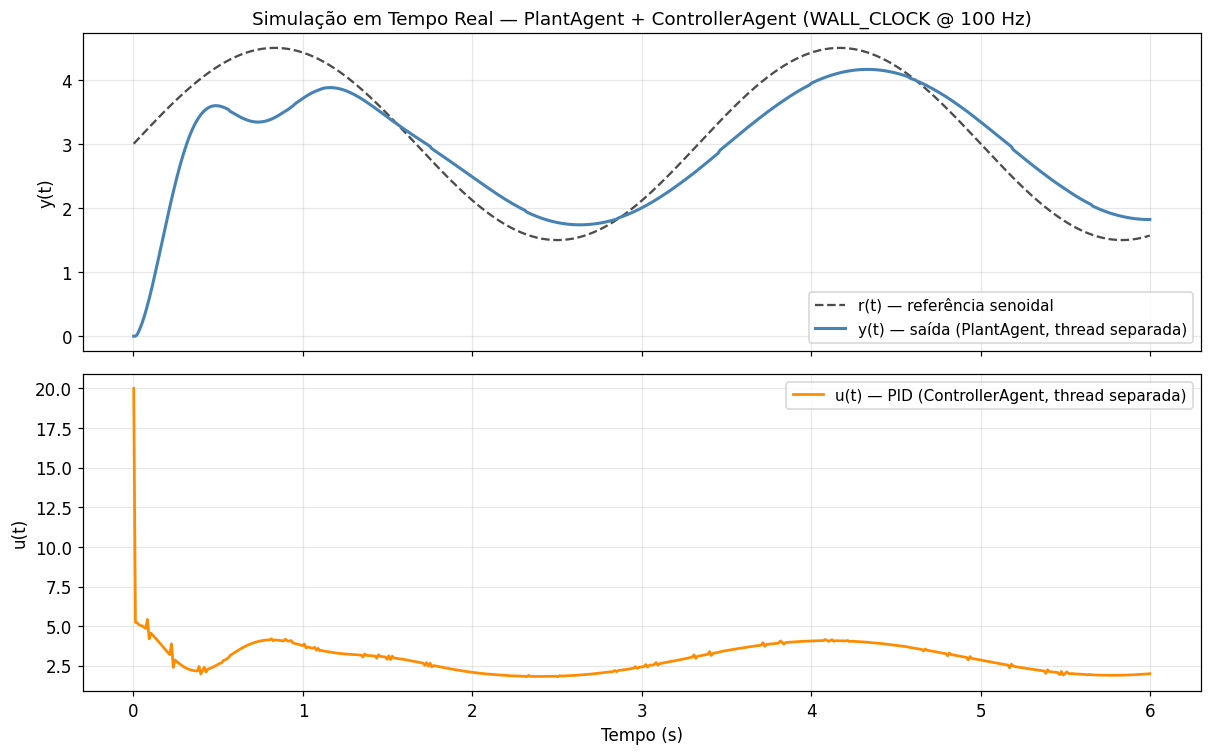

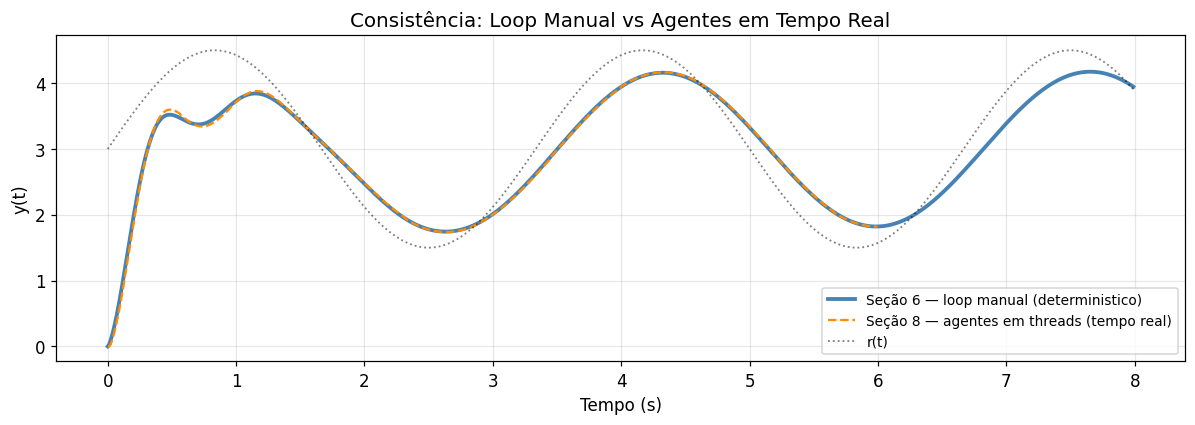

Os dois resultados devem ser próximos — pequenas diferenças são esperadas
devido ao jitter de agendamento do SO no modo WALL_CLOCK.


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(log_t, log_r, lw=1.5, color='k',          linestyle='--', alpha=0.7,
         label='r(t) — referência senoidal')
ax1.plot(log_t, log_y, lw=2.0, color='steelblue',
         label='y(t) — saída (PlantAgent, thread separada)')
ax1.set_ylabel('y(t)')
ax1.set_title('Simulação em Tempo Real — PlantAgent + ControllerAgent (WALL_CLOCK @ 100 Hz)',
              fontsize=12)
ax1.legend(fontsize=10)

ax2.plot(log_t, log_u, lw=1.8, color='darkorange',
         label='u(t) — PID (ControllerAgent, thread separada)')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('u(t)')
ax2.legend(fontsize=10)

fig.tight_layout()
plt.show()

# ── Comparação com simulação manual da Seção 6 ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts,     ys,     lw=2.5, color='steelblue',  label='Seção 6 — loop manual (deterministico)')
ax.plot(log_t,  log_y,  lw=1.5, color='darkorange', linestyle='--',
        label='Seção 8 — agentes em threads (tempo real)')
ax.plot(ts,     rs,     lw=1.2, color='k',          linestyle=':', alpha=0.5, label='r(t)')
ax.set_title('Consistência: Loop Manual vs Agentes em Tempo Real', fontsize=13)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('y(t)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print("Os dois resultados devem ser próximos — pequenas diferenças são esperadas")
print("devido ao jitter de agendamento do SO no modo WALL_CLOCK.")

---
## 9. Conclusão — Tabela Comparativa

Todas as seções usaram **o mesmo sistema**:

$$G(s) = \frac{25}{s^2 + 5s + 25}, \quad \omega_n=5\,\text{rad/s},\; \zeta=0{,}5$$

A tabela abaixo resume os resultados numéricos obtidos.

In [12]:
# ── Erro de discretização para diferentes passos ─────────────────────────────
print("=" * 65)
print(f"  Sistema de referência: G(s) = {WN**2:.0f} / (s² + {2*ZETA*WN:.0f}s + {WN**2:.0f})")
print(f"  ωn={WN} rad/s  |  ζ={ZETA}  |  ganho DC={1.0}")
print("=" * 65)

print("\n[Seção 2] Equivalência das representações:")
print(f"  TF contínua  vs  SS contínuo  : erro = {np.max(np.abs(y_tf - y_ss_i)):.2e}  (máquina)")
print(f"  TF contínua  vs  TF discreta  : erro = {np.max(np.abs(y_tf - y_tfd_i)):.5f}  (Δt={DT_CMP}s)")
print(f"  TF contínua  vs  evolve()     : erro = {np.max(np.abs(y_tf - y_man_i)):.5f}  (Δt={DT_CMP}s)")

print("\n[Seção 3] Erro de discretização por método  (Δt=0.05s):")
t_ref2, y_ref2 = step(G_tf)
for method in methods:
    G_d2 = c2d(G_tf, dt=0.05, method=method)
    t_d2, y_d2 = step(G_d2, n=int(3.0/0.05)+1)
    err2 = np.max(np.abs(y_ref2 - np.interp(t_ref2, t_d2, y_d2)))
    print(f"  {method:<15}: {err2:.5f}")

print("\n[Seção 4] Erro estacionário (controlador proporcional Kp=2):")
dc_cl = feedback(series(tf([2.0],[1]), G_tf)).evaluate(0).real
print(f"  e_ss = 1 - ganho DC = {1 - dc_cl:.4f}  (esperado: {1/(1+2*1):.4f})")

print("\n[Seção 6] PID em malha fechada:")
erro_pid = np.array(rs) - np.array(ys)
print(f"  Erro RMS em regime (t>2s) : {np.sqrt(np.mean(erro_pid[200:]**2)):.4f}")
print(f"  Erro pico absoluto        : {np.max(np.abs(erro_pid)):.4f}")

print("\n[Seção 7] LQR:")
print(f"  Ganho K   = {K}")
print(f"  Nbar      = {Nbar:.4f}")
print(f"  Polos MF  : {np.linalg.eigvals(A - B @ K)}")
print(f"  Regulação — estado final  : x = {x_reg}  (esperado: [0, 0])")
print(f"  Rastreamento — y_ss = {y_trk_hist[-1]:.6f}  (esperado: {SETPOINT_LQR})")

print("\n[Seção 8] Agentes em tempo real:")
print(f"  Amostras coletadas : {len(log_t)}")
print(f"  Taxa efetiva       : {len(log_t)/SIM_TIME:.1f} Hz  (nominal: {1/DT_AGT:.0f} Hz)")

print()
print("Resumo da API:")
rows = [
    ("Função de Transferência",   "tf(num, den)"),
    ("Espaço de Estados",         "ss(A, B, C, D)"),
    ("Resposta ao degrau",        "step(sys) → (t, y)"),
    ("Diagrama de Bode",          "bode(sys) → (ω, mag, phase)"),
    ("Realimentação",             "feedback(L)  ou  feedback(P, C)"),
    ("Discretização",             "c2d(sys, dt, method)"),
    ("Simulação passo-a-passo",   "sys.evolve(x, u) → (x_new, y)"),
    ("PID",                       "PID(Kp, Ki, Kd, dt, u_min, u_max)"),
    ("LQR",                       "lqr(A, B, Q, R) → (K, P)"),
    ("Simulação distribuída",     "PlantAgent + ControllerAgent + SharedMemoryTransport"),
]
print(f"  {'Funcionalidade':<30} {'API':<50}")
print("  " + "-" * 60)
for feat, api in rows:
    print(f"  {feat:<30} {api:<50}")

  Sistema de referência: G(s) = 25 / (s² + 5s + 25)
  ωn=5.0 rad/s  |  ζ=0.5  |  ganho DC=1.0

[Seção 2] Equivalência das representações:
  TF contínua  vs  SS contínuo  : erro = 1.55e-15  (máquina)
  TF contínua  vs  TF discreta  : erro = 0.00020  (Δt=0.01s)
  TF contínua  vs  evolve()     : erro = 0.00020  (Δt=0.01s)

[Seção 3] Erro de discretização por método  (Δt=0.05s):
  zoh            : 0.00668
  bilinear       : 0.06457
  euler          : 0.11678
  backward_diff  : 0.13623

[Seção 4] Erro estacionário (controlador proporcional Kp=2):
  e_ss = 1 - ganho DC = 0.3333  (esperado: 0.3333)

[Seção 6] PID em malha fechada:
  Erro RMS em regime (t>2s) : 0.3493
  Erro pico absoluto        : 3.0037

[Seção 7] LQR:
  Ganho K   = [[3.58257569 0.95178386]]
  Nbar      = 4.5826
  Polos MF  : [ -4.76828977 -24.02630668]
  Regulação — estado final  : x = [ 8.26929527e-11 -3.94303960e-10]  (esperado: [0, 0])
  Rastreamento — y_ss = 2.000000  (esperado: 2.0)

[Seção 8] Agentes em tempo real:
  A

---
## 10. Construtores de Matrizes — `mat`, `col`, `row`, `StateEquations`

**`synapsys.utils`** elimina o boilerplate de NumPy na construção das matrizes $(A, B, C, D)$.

| Helper | Formato | Uso |
|---|---|---|
| `mat(rows)` | $(m \times n)$ | qualquer matriz 2-D |
| `col(*values)` | $(n \times 1)$ | matriz de entrada **B** |
| `row(*values)` | $(1 \times n)$ | seletor de saída **C** |

`StateEquations` permite declarar cada equação diferencial **pelo nome do estado** em vez de gerenciar índices manualmente:

$$\dot{x}_i = \sum_j a_{ij}\,x_j + \sum_k b_{ik}\,u_k$$

Cada chamada `.eq(state, **coeffs)` preenche a linha correspondente de **A** (nomes de estados) e **B** (nomes de entradas).

A =
 [[ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]
 [-4.   2.  -0.1  0. ]
 [ 2.  -4.   0.  -0.1]]

B =
 [[0.]
 [0.]
 [0.]
 [2.]]

Matrizes idênticas à construção manual: True

StateSpace: StateSpace(n_states=4, n_inputs=1, n_outputs=2, continuous)
Estável: True


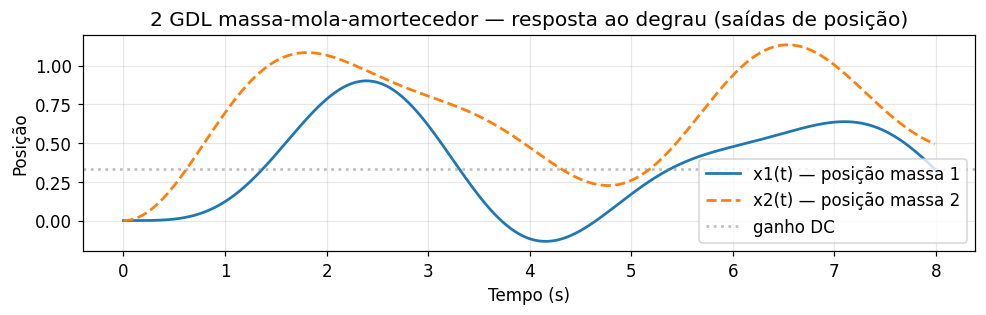


col(0, 0, 1).shape = (3, 1)
row(1, 0, 0).shape = (1, 3)


In [13]:
from synapsys.utils import mat, col, row, StateEquations
import numpy as np

# ── Sistema massa-mola-amortecedor de 2 GDL ─────────────────────────────────
# Vetor de estados: [x1, x2, v1, v2],  entrada: F
# ẋ1 = v1
# ẋ2 = v2
# v̇1 = -2k/m·x1 + k/m·x2 - c/m·v1
# v̇2 =  k/m·x1 - 2k/m·x2           - c/m·v2 + k/m·F

m, c, k = 1.0, 0.1, 2.0

eqs = (
    StateEquations(states=["x1", "x2", "v1", "v2"], inputs=["F"])
    .eq("x1", v1=1)
    .eq("x2", v2=1)
    .eq("v1", x1=-2*k/m, x2=k/m,  v1=-c/m)
    .eq("v2", x1=k/m,  x2=-2*k/m, v2=-c/m, F=k/m)
)

print("A =\n", eqs.A)
print("\nB =\n", eqs.B)

# ── Matrizes equivalentes construídas manualmente (para comparação) ──────────
A_manual = mat([
    [0,        0,       1,     0    ],
    [0,        0,       0,     1    ],
    [-2*k/m,   k/m,  -c/m,    0    ],
    [k/m,   -2*k/m,    0,   -c/m   ],
])
B_manual = col(0, 0, 0, k/m)

print("\nMatrizes idênticas à construção manual:",
      np.allclose(eqs.A, A_manual) and np.allclose(eqs.B, B_manual))

# ── Montar StateSpace e simular ───────────────────────────────────────────────
from synapsys.api import ss, c2d, step

C = eqs.output("x1", "x2")        # observar posições
D = np.zeros((2, 1))
G_2dof = ss(eqs.A, eqs.B, C, D)

print(f"\nStateSpace: {G_2dof}")
print(f"Estável: {G_2dof.is_stable()}")

# ── Resposta ao degrau da posição x1 ─────────────────────────────────────────
G_d = c2d(G_2dof, dt=0.01)
t, Y = step(G_d, n=800)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, Y[:, 0], label="x1(t) — posição massa 1")
ax.plot(t, Y[:, 1], label="x2(t) — posição massa 2", ls="--")
ax.axhline(Y[-1, 0], color="gray", ls=":", alpha=0.5, label="ganho DC")
ax.set_title("2 GDL massa-mola-amortecedor — resposta ao degrau (saídas de posição)")
ax.set_xlabel("Tempo (s)"); ax.set_ylabel("Posição")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# ── demo row / col ────────────────────────────────────────────────────────────
print("\ncol(0, 0, 1).shape =", col(0, 0, 1).shape)    # (3, 1)
print("row(1, 0, 0).shape =", row(1, 0, 0).shape)    # (1, 3)